In [1]:
# Importing library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# url dataset
url = r"https://github.com/itsmathematicsboy/Machine-Learning-and-Deep-Learning-Course/raw/main/Machine%20Learning/score_updated.csv"

In [3]:
# function getting data
def get_data(url_data):
    return pd.read_csv(url_data)

In [4]:
# importing data
df = get_data(url)

In [5]:
# Showing the first 5th data
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [6]:
# Information About Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   96 non-null     float64
 1   Scores  96 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 1.6 KB


In [7]:
# Descriptive Statistics of Data
df.describe()

,Hours,Scores
count,96.000000,96.000000
mean,5.267708,54.020833
std,2.503030,25.017459
min,1.000000,12.000000
25%,3.075000,30.750000
50%,5.250000,54.500000
75%,7.325000,74.250000
max,9.800000,99.000000


In [8]:
# Checking the duplicated value
df.duplicated().sum()

1

In [9]:
# Delete the duplicates
df.drop_duplicates(inplace = True)

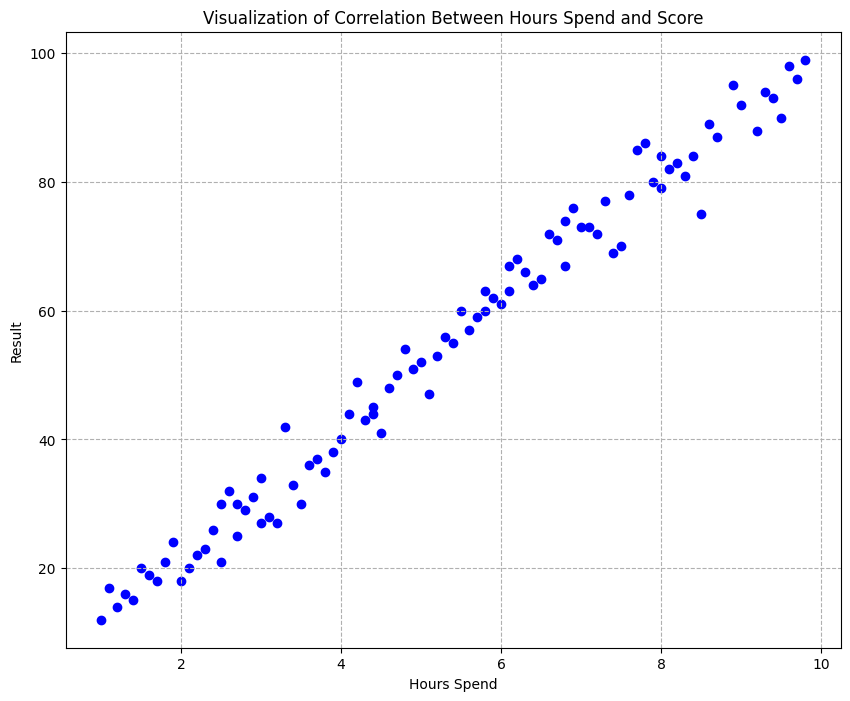

In [10]:
# Visualizing the data
plt.figure(figsize = (10, 8))
plt.scatter(df['Hours'], df['Scores'], color = 'blue')
plt.title('Visualization of Correlation Between Hours Spend and Score')
plt.xlabel('Hours Spend')
plt.ylabel('Result')
plt.grid(True, linestyle = '--')
plt.show()

In [11]:
# Initialize the x and y variable
x = np.array(df['Hours'].values).reshape(-1, 1)
y = np.array(df['Scores'].values).reshape(-1, 1)

In [12]:
# split the train test data
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = .7, random_state = None)

In [13]:
# initialize the scaling
scaler = StandardScaler()

In [14]:
# initialize for Scaling x and y
scaler_x = scaler
scaler_y = scaler

In [15]:
# scaling the data
x_train_scaler = scaler_x.fit_transform(x_train)
x_test_scaler = scaler_x.fit_transform(x_test)
y_train_scaler = scaler_y.fit_transform(y_train)
y_test_scaler = scaler.fit_transform(y_test)

In [16]:
# initialize the model
model = LinearRegression()

In [17]:
# train the model with data training
model.fit(x_train_scaler, y_train_scaler)

LinearRegression()

In [18]:
# predict data testing
y_pred = model.predict(x_test_scaler)

In [19]:
# function for metrics error
def mae(yt, yp):
    return mean_absolute_error(yt, yp)

def mse(yt, yp):
    return mean_squared_error(yt, yp)

def r2(yt, yp):
    return r2_score(yt, yp)

In [20]:
# result for metrics error
print('Mean Absolute Error:', mae(y_test_scaler, y_pred))
print('Mean Squared Error:', mse(y_test_scaler, y_pred))
print('R2 Score', r2(y_test_scaler, y_pred))

Mean Absolute Error: 0.10026643303649464
Mean Squared Error: 0.015344447733827059
R2 Score 0.984655552266173
